In [35]:
### 1. IMPORT LIBRARIES:-
# Import necessary libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt

# Import machine learning tools
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [36]:
### 2. LOAD DATASET:-
# Load the dataset from the data folder
data = pd.read_csv("../data/netflix.csv")

# Display first few rows to understand the structure
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [37]:
### 3. HANDLE MISSING VALUES:-
# Fill missing values using the most frequent value in each column
data.fillna(data.mode().iloc[0], inplace=True)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,"Raúl Campos, Jan Suter","João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...
...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,"Raúl Campos, Jan Suter",Nasty C,United States,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,"Raúl Campos, Jan Suter","Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...


In [38]:
### 4. ENCODE CATEGORICAL DATA:-
# Convert categorical columns into numerical values using Label Encoding
encoder = LabelEncoder()

data['type'] = encoder.fit_transform(data['type'])
data['rating'] = encoder.fit_transform(data['rating'])

In [39]:
### 5. FEATURE ENGINEERING:-
# Extract numeric values from duration column (e.g., "90 min" → 90)
data['duration_num'] = data['duration'].str.extract(r'(\d+)').astype(float)

In [40]:
### 6. SELECT FEATURES:-
# Select important features for clustering
features = data[['release_year', 'duration_num', 'type']]

In [41]:
### 7. FEATURE SCALING:-
# Scale the features to bring them to the same range
scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [42]:
### 8. APPLY PCA:-
# Reduce dimensions using PCA for better clustering performance
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# Check how much variance is retained
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.65765976 0.30492123]


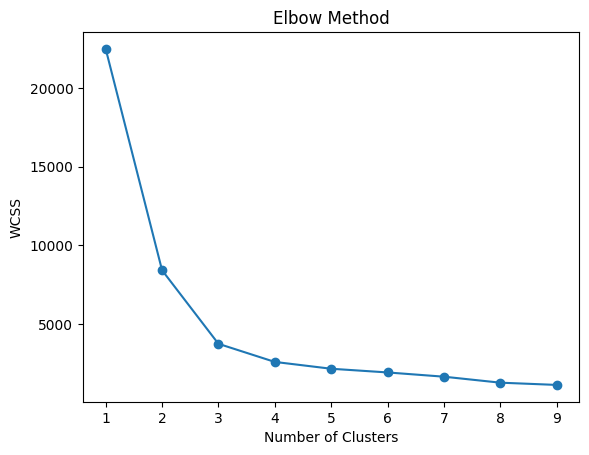

In [43]:
### 9. ELBOW METHOD:-
# Use Elbow Method to find optimal number of clusters
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pca_data)
    wcss.append(kmeans.inertia_)

# Plot the elbow graph
plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [44]:
### 10. APPLY K-MEANS:-
# Apply K-Means clustering with optimal clusters (k=3)
model = KMeans(n_clusters=3, random_state=42)

# Assign cluster labels
clusters = model.fit_predict(pca_data)

# Add cluster labels to dataset
data['cluster'] = clusters

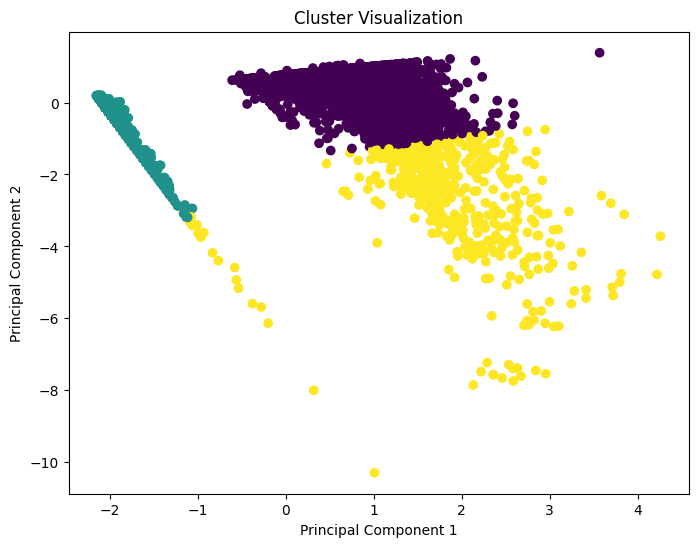

In [45]:
### 11. VISUALIZE CLUSTERS:-
# Plot clusters using PCA components
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=clusters)
plt.title("Cluster Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

In [46]:
### 12. EVALUATE MODEL
# Calculate Silhouette Score to evaluate clustering performance
score = silhouette_score(pca_data, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.7470654435150479


In [47]:
### 13. CLUSTER ANALYSIS
# Analyze average values of features in each cluster
data.groupby('cluster')[['release_year', 'duration_num']].mean()

,release_year,duration_num
cluster,,
0,2015.291270,97.856593
1,2016.488926,1.765984
2,1985.868709,111.411379


In [48]:
# Extract year_added
data['year_added'] = pd.to_datetime(data['date_added'], errors='coerce').dt.year

# Number of genres
data['num_genres'] = data['listed_in'].str.split(',').apply(len)

# Number of actors
data['num_cast'] = data['cast'].str.split(',').apply(len)

# Number of countries
data['num_countries'] = data['country'].str.split(',').apply(len)

In [49]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['rating'] = encoder.fit_transform(data['rating'])
data['director'] = encoder.fit_transform(data['director'])

In [50]:
# Title length (number of characters in title)
data['title_length'] = data['title'].astype(str).apply(len)

# Description length (number of characters in description)
data['desc_length'] = data['description'].astype(str).apply(len)

In [51]:
data[['title', 'title_length', 'desc_length']].head()

,title,title_length,desc_length
0,3%,2,136
1,7:19,4,148
2,23:59,5,149
3,9,1,145
4,21,2,143


In [52]:
features = data[[
    'release_year',
    'year_added',
    'duration_num',
    'type',
    'rating',
    'num_genres',
    'num_cast',
    'num_countries',
    'director',
    'title_length',
    'desc_length'
]]

# Data was grouped into clusters based on similarity
# PCA helped simplify the dataset
# Clusters show patterns in content type and duration
# Model can help in recommendation systems

## Final Conclusion:-

-> In this part of the project, machine learning techniques were used to analyze and group Netflix content based on important features.

-> The dataset was first prepared by cleaning missing values and converting categorical columns into numerical form so that they could be used in the model. A new numerical feature was also extracted from the duration column to make the data more meaningful for analysis.

-> To simplify the dataset and reduce complexity, Principal Component Analysis (PCA) was applied. This helped in transforming the data   into fewer dimensions while still keeping the important patterns.

-> After that, K-Means clustering was used to divide the content into different groups. The number of clusters was selected using the Elbow Method, and the quality of clustering was checked using the Silhouette Score.

-> The results show that Netflix content can be grouped based on similarities such as release year, duration, and type. These clusters give a better understanding of how content is structured and can be useful in building recommendation systems.

-> Overall, this section shows how unsupervised learning can be applied to real-world data to discover useful patterns without predefined labels.